# Gradient Descent From Scratch (NumPy only)

**Goal:** show that gradient descent minimises a loss function, using nothing but NumPy for the maths and Matplotlib for plots.

**What this notebook does**
1. Defines a simple loss, $L(w) = (w-3)^2$, and derives its gradient by hand.
2. Implements gradient descent and stores the loss at every iteration.
3. Plots the loss curve and shows that it converges to the minimum at $w = 3$.
4. Compares learning rates (too small, good, oscillating, too large).
5. Answers the three checkpoint questions in my own words.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The loss function and its derivative

$$L(w) = (w-3)^2$$

This is a parabola. Its minimum is at $w = 3$, where the loss is $0$. Pretending we *don't* know that, we want gradient descent to find it.

**Deriving the gradient with the chain rule.** Let $u = w - 3$, so $L = u^2$:

$$\frac{dL}{du} = 2u \qquad \frac{du}{dw} = 1$$

$$\frac{dL}{dw} = \frac{dL}{du}\cdot\frac{du}{dw} = 2u \cdot 1 = 2(w-3)$$

This is the same chain-rule pattern I will use in backpropagation: multiply local derivatives along the path from the loss back to the parameter.

**The update rule**

$$w := w - \alpha \, \frac{dL}{dw}$$

- $\alpha$ is the learning rate (step size).
- $\frac{dL}{dw}$ points in the direction the loss *increases*, so we subtract it to make the loss *decrease*.

In [4]:
def loss(w):
    # L(w) = (w - 3)^2
    return (w - 3) ** 2


def gradient(w):
    # dL/dw = 2(w - 3), derived by hand above
    return 2 * (w - 3)


# Sanity checks: gradient is 0 at the minimum, negative to the left, positive to the right
print("gradient at w=3 :", gradient(3.0))   # 0  -> flat, we are at the bottom
print("gradient at w=0 :", gradient(0.0))   # -6 -> loss falls as w increases
print("gradient at w=6 :", gradient(6.0))   # +6 -> loss falls as w decreases

gradient at w=3 : 0.0
gradient at w=0 : -6.0
gradient at w=6 : 6.0


## 2. Gradient descent

Each iteration:
1. compute the gradient at the current $w$,
2. move $w$ a small step *against* the gradient,
3. record the new loss.

In [5]:
def gradient_descent(w0, lr, n_iters):
    # Run gradient descent on L(w) = (w-3)^2.
    # Returns the history of w and the history of the loss (both include the starting point).
    w = w0
    w_history = [w]
    loss_history = [loss(w)]

    for _ in range(n_iters):
        grad = gradient(w)      # how the loss changes with w at this point
        w = w - lr * grad       # step against the gradient
        w_history.append(w)
        loss_history.append(loss(w))

    return np.array(w_history), np.array(loss_history)

In [6]:
w0 = 0.0        # starting guess (far from the minimum at 3)
lr = 0.1        # learning rate
n_iters = 50    # number of updates

w_hist, loss_hist = gradient_descent(w0, lr, n_iters)

print("iter |      w      |    loss    |  gradient  |  update (-lr*grad)")
for i in range(6):
    g = gradient(w_hist[i])
    print(f"{i:4d} | {w_hist[i]:11.6f} | {loss_hist[i]:10.6f} | {g:10.6f} | {-lr * g:10.6f}")

print("\nStarting w :", w0)
print("Final w    :", w_hist[-1])
print("Final loss :", loss_hist[-1])
print("Loss decreased at every step:", bool(np.all(np.diff(loss_hist) < 0)))

iter |      w      |    loss    |  gradient  |  update (-lr*grad)
   0 |    0.000000 |   9.000000 |  -6.000000 |   0.600000
   1 |    0.600000 |   5.760000 |  -4.800000 |   0.480000
   2 |    1.080000 |   3.686400 |  -3.840000 |   0.384000
   3 |    1.464000 |   2.359296 |  -3.072000 |   0.307200
   4 |    1.771200 |   1.509949 |  -2.457600 |   0.245760
   5 |    2.016960 |   0.966368 |  -1.966080 |   0.196608

Starting w : 0.0
Final w    : 2.9999571825692186
Final loss : 1.8333323787185533e-09
Loss decreased at every step: True


## 3. Loss curve

Left: loss against iteration. Right: the same curve on a log scale. A straight line on a log scale means the loss shrinks by a constant *factor* each step (geometric convergence).

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_hist, marker="o", markersize=3)
axes[0].set_title("Loss curve (linear scale)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss  L(w)")
axes[0].grid(alpha=0.3)

axes[1].semilogy(loss_hist, marker="o", markersize=3, color="tab:orange")
axes[1].set_title("Loss curve (log scale)")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss  L(w)  (log)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### The path on the parabola

Each dot is one value of $w$. The steps get smaller as we approach the minimum because the gradient $2(w-3)$ shrinks towards $0$.

ws = np.linspace(-1, 7, 200)

plt.figure(figsize=(7, 4))
plt.plot(ws, loss(ws), label="L(w) = (w-3)^2")
plt.plot(w_hist[:15], loss(w_hist[:15]), "o-", color="tab:red", label="first 15 steps")
plt.scatter([w_hist[0]], [loss(w_hist[0])], color="green", zorder=5, label="start")
plt.axvline(3, color="gray", linestyle="--", label="minimum at w=3")
plt.title("Gradient descent walking down the loss surface")
plt.xlabel("w")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Effect of the learning rate

For this loss, one update gives:

$$w_{t+1} - 3 = (1 - 2\alpha)\,(w_t - 3)$$

so the distance from the minimum is multiplied by $(1 - 2\alpha)$ each step:

| learning rate | factor $\lvert 1-2\alpha \rvert$ | behaviour |
|---|---|---|
| $\alpha = 0.01$ | 0.98 | converges, but very slowly (too small) |
| $\alpha = 0.1$ | 0.80 | converges smoothly (good) |
| $\alpha = 0.9$ | 0.80 | converges but **oscillates** across the minimum (factor is negative) |
| $\alpha = 1.1$ | 1.20 | **diverges**: each step overshoots by more than it corrects |

The rule for this loss: it converges only for $0 < \alpha < 1$.

 lr   | factor |  final w        | final loss
 0.01 |   0.98 |        1.363547 | 2.67798
 0.10 |   0.80 |        2.996286 | 1.37925e-05
 0.90 |   0.80 |        2.996286 | 1.37925e-05
 1.10 |   1.20 |     -709.128941 | 507128


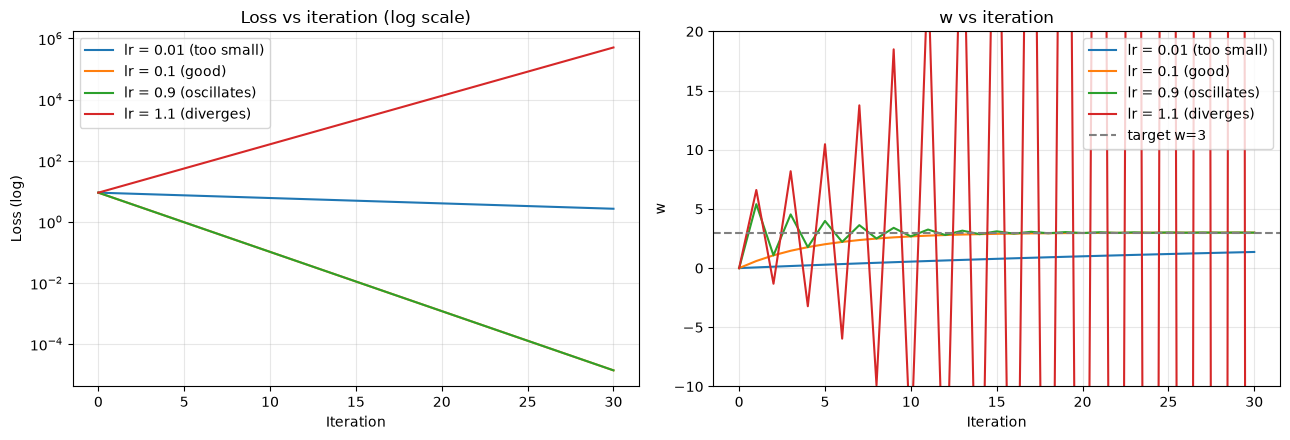

In [7]:
learning_rates = [0.01, 0.1, 0.9, 1.1]
labels = ["0.01 (too small)", "0.1 (good)", "0.9 (oscillates)", "1.1 (diverges)"]
n_iters = 30

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

print(" lr   | factor |  final w        | final loss")
for lr_i, label in zip(learning_rates, labels):
    w_h, l_h = gradient_descent(0.0, lr_i, n_iters)
    axes[0].semilogy(l_h, label=f"lr = {label}")
    axes[1].plot(w_h, label=f"lr = {label}")
    print(f"{lr_i:5.2f} | {abs(1 - 2 * lr_i):6.2f} | {w_h[-1]:15.6f} | {l_h[-1]:.6g}")

axes[0].set_title("Loss vs iteration (log scale)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (log)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(3, color="gray", linestyle="--", label="target w=3")
axes[1].set_ylim(-10, 20)
axes[1].set_title("w vs iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("w")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()